# Exploración del dataset con RAPIDS (cuDF / CuPy)

La transformación de la clase ternaria se ejecuta de forma vectorizada en GPU. `cuML` no se importa porque esta notebook todavía no entrena modelos.

## Librerías

In [2]:
import os
import cudf
import cupy as cp
import matplotlib.pyplot as plt

print('cuDF:', cudf.__version__)
print('GPU:', cp.cuda.runtime.getDeviceProperties(0)['name'].decode())

cuDF: 26.08.01
GPU: NVIDIA GeForce RTX 3090


## URLs y constantes

In [3]:
BASE_URL = os.path.join('/mnt/', 'c')
BASE_DATA_URL = os.path.join('/mnt/', 'e')
COMP_URL = os.path.join(BASE_URL, 'Users', 'marco', 'Desktop', 'MASTER', 'MASTER', 'DMEyF', 'COMP1')
DATA_URL = os.path.join(BASE_DATA_URL, 'DATASETS', 'DMEyF', 'competencia_01_crudo.csv')

## Lectura de datos en GPU

In [4]:
df = cudf.read_csv(
    DATA_URL,
    dtype={'numero_de_cliente': 'int32', 'foto_mes': 'int32'}
)

In [5]:
df.head()

,numero_de_cliente,foto_mes,active_quarter,cliente_vip,internet,cliente_edad,cliente_antiguedad,mrentabilidad,mrentabilidad_annual,mcomisiones,...,Visa_madelantodolares,Visa_fultimo_cierre,Visa_mpagado,Visa_mpagospesos,Visa_mpagosdolares,Visa_fechaalta,Visa_mconsumototal,Visa_cconsumos,Visa_cadelantosefectivo,Visa_mpagominimo
0,12159854,202103,1,0,0,56,134,688.41,26701.84,98.82,...,0.0,1,0.0,-16247.77,0.0,4056,15732.34,1,0,1137.81
1,12159858,202103,1,0,0,48,102,78.43,24418.75,-73.62,...,NaN,<NA>,NaN,NaN,NaN,<NA>,NaN,<NA>,<NA>,NaN
2,12160484,202103,1,0,0,60,55,8101.55,3162.23,13399.50,...,0.0,1,0.0,-31103.23,0.0,1632,2860.54,2,0,19858.89
3,12160591,202103,1,0,0,46,275,14825.78,138050.05,1146.27,...,0.0,1,0.0,-13733.44,0.0,2122,1419.36,3,0,1231.65
4,12160747,202103,1,0,0,47,194,2015.61,31240.49,1791.25,...,0.0,1,0.0,0.0,0.0,5901,1286.93,1,0,82.11


In [6]:
df.describe()

,numero_de_cliente,foto_mes,active_quarter,cliente_vip,internet,cliente_edad,cliente_antiguedad,mrentabilidad,mrentabilidad_annual,mcomisiones,...,Visa_madelantodolares,Visa_fultimo_cierre,Visa_mpagado,Visa_mpagospesos,Visa_mpagosdolares,Visa_fechaalta,Visa_mconsumototal,Visa_cconsumos,Visa_cadelantosefectivo,Visa_mpagominimo
count,9.830610e+05,983061.000000,983061.000000,983061.000000,983061.000000,983061.000000,983061.000000,983061.000000,9.830610e+05,983061.000000,...,855301.000000,935525.000000,9.358750e+05,8.553010e+05,855301.000000,935875.000000,8.553010e+05,855301.000000,855301.000000,9.358750e+05
mean,3.779804e+07,202105.506242,0.986954,0.003166,0.049117,46.884686,134.912766,2445.401757,2.484136e+04,1614.815041,...,0.026915,5.699941,6.631840e+03,-4.040167e+04,7.407502,3245.136853,2.342605e+04,8.171195,0.008112,6.828315e+03
std,1.586811e+07,1.707532,0.113472,0.056175,0.271282,12.987574,86.282920,8267.171556,6.822922e+04,3122.676446,...,4.733806,8.690398,2.824518e+04,5.785297e+04,113.542213,2246.969985,4.595059e+04,10.037463,0.192377,2.686818e+04
min,4.000000e+00,202103.000000,0.000000,0.000000,0.000000,18.000000,1.000000,-271488.390000,-9.380887e+05,-52407.900000,...,0.000000,0.000000,0.000000e+00,-3.280279e+06,0.000000,1.000000,-4.593328e+05,0.000000,0.000000,0.000000e+00
25%,2.549492e+07,202104.000000,1.000000,0.000000,0.000000,37.000000,63.000000,71.110000,1.884690e+03,366.730000,...,0.000000,2.000000,0.000000e+00,-4.927173e+04,0.000000,1424.000000,2.328830e+03,2.000000,0.000000,6.686100e+02
50%,3.596049e+07,202106.000000,1.000000,0.000000,0.000000,45.000000,128.000000,1416.530000,1.334347e+04,981.750000,...,0.000000,5.000000,0.000000e+00,-2.446880e+04,0.000000,2943.000000,1.024627e+04,5.000000,0.000000,2.463300e+03
75%,4.905971e+07,202107.000000,1.000000,0.000000,0.000000,56.000000,190.000000,3304.210000,3.206790e+04,2181.850000,...,0.000000,7.000000,0.000000e+00,-1.072019e+04,0.000000,4841.000000,2.776373e+04,11.000000,0.000000,6.146520e+03
max,7.825496e+07,202108.000000,1.000000,1.000000,4.000000,101.000000,380.000000,784129.030000,7.023011e+06,513155.480000,...,2062.110000,3443.000000,2.533917e+06,7.694699e+05,17196.390000,12751.000000,9.220294e+06,240.000000,19.000000,1.141511e+07


In [7]:
nas = df.isna().sum()
nas[nas > 0]

mtarjeta_visa_descuentos        20694
mtarjeta_master_descuentos      29178
Master_delinquency              99644
Master_status                   99644
Master_mfinanciacion_limite     99644
Master_Fvencimiento             99644
Master_Finiciomora             978240
Master_msaldototal              99644
Master_msaldopesos              99644
Master_msaldodolares            99644
Master_mconsumospesos          579470
Master_mconsumosdolares        579470
Master_mlimitecompra            99644
Master_madelantopesos          579470
Master_madelantodolares        579470
Master_fultimo_cierre          100127
Master_mpagado                  99644
Master_mpagospesos             579470
Master_mpagosdolares           579470
Master_fechaalta                99644
Master_mconsumototal           579470
Master_cconsumos               579470
Master_cadelantosefectivo      579470
Master_mpagominimo              99644
Visa_delinquency                47186
Visa_status                     47186
Visa_mfinanc

## Columnas

In [8]:
for column in df.columns:
    print(column)

numero_de_cliente
foto_mes
active_quarter
cliente_vip
internet
cliente_edad
cliente_antiguedad
mrentabilidad
mrentabilidad_annual
mcomisiones
mactivos_margen
mpasivos_margen
cproductos
tcuentas
ccuenta_corriente
mcuenta_corriente_adicional
mcuenta_corriente
ccaja_ahorro
mcaja_ahorro
mcaja_ahorro_adicional
mcaja_ahorro_dolares
cdescubierto_preacordado
mcuentas_saldo
ctarjeta_debito
ctarjeta_debito_transacciones
mautoservicio
ctarjeta_visa
ctarjeta_visa_transacciones
mtarjeta_visa_consumo
ctarjeta_master
ctarjeta_master_transacciones
mtarjeta_master_consumo
cprestamos_personales
mprestamos_personales
cprestamos_prendarios
mprestamos_prendarios
cprestamos_hipotecarios
mprestamos_hipotecarios
cplazo_fijo
mplazo_fijo_dolares
mplazo_fijo_pesos
cinversion1
minversion1_pesos
minversion1_dolares
cinversion2
minversion2
cseguro_vida
cseguro_auto
cseguro_vivienda
cseguro_accidentes_personales
ccaja_seguridad
cpayroll_trx
mpayroll
mpayroll2
cpayroll2_trx
ccuenta_debitos_automaticos
mcuenta_debitos

## Clientes individuales

In [9]:
df['numero_de_cliente'].max()

np.int32(78254956)

In [10]:
n_clientes = df['numero_de_cliente'].nunique()
print(f'tenemos {n_clientes} clientes individuales en {len(df)} registros')
df['numero_de_cliente'].value_counts()

tenemos 169727 clientes individuales en 983061 registros


numero_de_cliente
12159854    6
12159858    6
12160484    6
12160591    6
12160747    6
           ..
78249586    1
78249850    1
78250419    1
78253625    1
78254956    1
Name: count, Length: 169727, dtype: int64

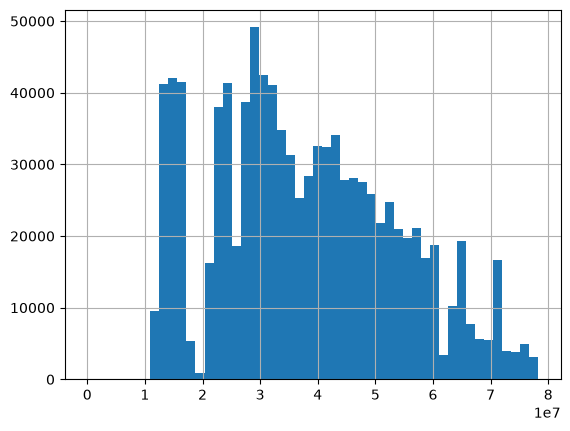

In [11]:
# Matplotlib trabaja en CPU: se transfiere únicamente esta serie para graficar.
df['numero_de_cliente'].to_pandas().hist(bins=50)
plt.show()

In [12]:
df.groupby('numero_de_cliente').sum()

,foto_mes,active_quarter,cliente_vip,internet,cliente_edad,cliente_antiguedad,mrentabilidad,mrentabilidad_annual,mcomisiones,mactivos_margen,...,Visa_madelantodolares,Visa_fultimo_cierre,Visa_mpagado,Visa_mpagospesos,Visa_mpagosdolares,Visa_fechaalta,Visa_mconsumototal,Visa_cconsumos,Visa_cadelantosefectivo,Visa_mpagominimo
numero_de_cliente,,,,,,,,,,,,,,,,,,,,,
41089550,1212633,6,0,0,187,771,-327.42,17735.19,-576.50,-230.06,...,0.0,17,6233.05,-49247.36,58.91,5623,7769.9,17,0,8867.88
54772422,1212633,6,0,10,180,309,24682.19,176575.48,11884.65,5771.13,...,0.0,142,396269.98,-467095.72,0.0,9397,173920.15,31,0,402268.62
27785455,1212633,6,0,0,311,849,25447.10,276174.83,16290.35,7098.06,...,NaN,<NA>,NaN,NaN,NaN,<NA>,NaN,<NA>,<NA>,NaN
71021434,1212633,6,0,0,252,135,10556.02,6642.50,1803.42,5054.16,...,0.0,17,0.0,-152480.19,11.55,3415,69676.37,69,0,10369.32
28126849,1212633,6,0,0,294,1263,9058.92,85404.82,2749.00,51.14,...,0.0,17,0.0,-17521.63,0.0,6469,11958.47,16,0,1114.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36714079,1212633,6,0,0,237,993,-111242.52,-603829.22,21178.79,-133481.69,...,0.0,58,113536.76,-1527054.29,0.0,27601,551382.73,111,0,256640.67
55540059,1212633,6,0,0,150,411,15682.10,114409.87,10353.83,-271.97,...,0.0,17,0.0,-13360.85,0.0,11605,0.0,0,0,926.67
34370903,1212633,6,0,0,372,1041,11471.93,152736.74,15813.20,-21763.47,...,0.0,17,0.0,-171624.21,0.0,29155,57178.74,54,0,22380.84


## Control de cliente-mes

Se valida directamente sobre pares `(numero_de_cliente, foto_mes)`, sin crear listas Python por cliente.

In [13]:
ordenado = df[['numero_de_cliente', 'foto_mes']].sort_values(
    ['numero_de_cliente', 'foto_mes']
)

duplicados = ordenado.duplicated(['numero_de_cliente', 'foto_mes']).sum()

# Índice mensual consecutivo: funciona también entre diciembre y enero.
year = ordenado['foto_mes'] // 100
month = ordenado['foto_mes'] % 100
ordenado['mes_idx'] = year * 12 + month
ordenado['salto'] = ordenado.groupby('numero_de_cliente')['mes_idx'].diff()

gaps = (ordenado['salto'] > 1).sum()
print('Pares cliente-mes duplicados:', int(duplicados))
print('Gaps mensuales:', int(gaps))

Pares cliente-mes duplicados: 0
Gaps mensuales: 23


# Clase ternaria vectorizada en GPU

Para cada registro se consulta mediante `merge` si el mismo cliente aparece en los meses siguientes. Esto evita el `apply(axis=1)` y la búsqueda repetida en todo `cliente_mes`.

In [28]:
# Índice de mes continuo para cada fila.
year = df['foto_mes'] // 100
month = df['foto_mes'] % 100
df['mes_idx'] = year * 12 + month

# Tabla de existencia: una fila por cliente y mes.
presencia = (
    df[['numero_de_cliente', 'mes_idx']]
    .drop_duplicates()
    .assign(presente=cp.int8(1))
)

# Presencia en t+1: desplazamos la clave para que coincida con el mes actual t.
presencia_t1 = presencia.rename(columns={'mes_idx': 'mes_idx_t1', 'presente': 'presente_t1'})
presencia_t1['mes_idx'] = presencia_t1['mes_idx_t1'] - 1
presencia_t1 = presencia_t1[['numero_de_cliente', 'mes_idx', 'presente_t1']]

# Presencia en t+2.
presencia_t2 = presencia.rename(columns={'mes_idx': 'mes_idx_t2', 'presente': 'presente_t2'})
presencia_t2['mes_idx'] = presencia_t2['mes_idx_t2'] - 2
presencia_t2 = presencia_t2[['numero_de_cliente', 'mes_idx', 'presente_t2']]

df = df.merge(presencia_t1, on=['numero_de_cliente', 'mes_idx'], how='left')
df = df.merge(presencia_t2, on=['numero_de_cliente', 'mes_idx'], how='left')

tiene_t1 = df['presente_t1'].fillna(0).astype('bool')
tiene_t2 = df['presente_t2'].fillna(0).astype('bool')

# Último mes observado del dataset: no tiene horizonte futuro verificable.
ultimo_mes_idx = int(df['mes_idx'].max())

df['ternaria'] = cudf.Series(None, index=df.index, dtype='str')
df.loc[df['mes_idx'] < ultimo_mes_idx - 1, 'ternaria'] = 'baja+1'
df.loc[(df['mes_idx'] < ultimo_mes_idx - 1) & tiene_t1, 'ternaria'] = 'baja+2'
df.loc[(df['mes_idx'] < ultimo_mes_idx - 1) & tiene_t1 & tiene_t2, 'ternaria'] = 'continua'

# Penúltimo mes: sólo puede determinarse baja+1; si continúa queda sin clase.
df.loc[(df['mes_idx'] == ultimo_mes_idx - 1) & ~tiene_t1, 'ternaria'] = 'baja+1'

# Quitamos columnas auxiliares.
df = df.drop(columns=['mes_idx', 'presente_t1', 'presente_t2'])

In [15]:
df['ternaria'].value_counts(dropna=False)

ternaria
continua    645999
NaN         327892
baja+1        5103
baja+2        4067
Name: count, dtype: int64

In [16]:
cudf.crosstab(df['ternaria'].fillna('NA'), df['foto_mes'])

foto_mes,202103,202104,202105,202106,202107,202108
ternaria,,,,,,
NA,0,0,0,0,163245,164647
baja+1,1019,964,1143,874,1103,0
baja+2,960,1139,870,1098,0,0
continua,160921,161181,161755,162142,0,0


## Conversión opcional

Sólo si una librería posterior exige Pandas/NumPy, transferí el resultado al final. Mientras el pipeline continúe con RAPIDS o XGBoost CUDA, conviene mantenerlo en GPU.

In [20]:
df["mes_idx"] = year * 12 + month

In [21]:
df["mes_idx"]

0         24255
1         24255
2         24255
3         24255
4         24255
          ...  
983056    24260
983057    24260
983058    24260
983059    24260
983060    24260
Name: mes_idx, Length: 983061, dtype: int32

In [22]:
presencia = (
    df[["numero_de_cliente", "mes_idx"]]
    .drop_duplicates()
    .assign(presente=1)
)
presencia

,numero_de_cliente,mes_idx,presente
0,13463502,24255,1
1,13463747,24255,1
2,13463979,24255,1
3,13464103,24255,1
4,13464114,24255,1
...,...,...,...
983004,52542633,24260,1
983005,52543388,24260,1
983006,71290130,24260,1
983007,71289347,24260,1


In [26]:
presencia_t1 = presencia.rename(
    columns={
        "mes_idx": "mes_idx_t1",
        "presente": "presente_t1"
    }
)

presencia_t1["mes_idx"] = presencia_t1["mes_idx_t1"] - 1
presencia_t1

,numero_de_cliente,mes_idx_t1,presente_t1,mes_idx
0,13463502,24255,1,24254
1,13463747,24255,1,24254
2,13463979,24255,1,24254
3,13464103,24255,1,24254
4,13464114,24255,1,24254
...,...,...,...,...
983004,52542633,24260,1,24259
983005,52543388,24260,1,24259
983006,71290130,24260,1,24259
983007,71289347,24260,1,24259


In [27]:
presencia_t2 = presencia.rename(
    columns={
        "mes_idx": "mes_idx_t2",
        "presente": "presente_t2"
    }
)

presencia_t2["mes_idx"] = presencia_t2["mes_idx_t2"] - 2

presencia_t2 = presencia_t2[
    ["numero_de_cliente", "mes_idx", "presente_t2"]
]
presencia_t2

,numero_de_cliente,mes_idx,presente_t2
0,13463502,24253,1
1,13463747,24253,1
2,13463979,24253,1
3,13464103,24253,1
4,13464114,24253,1
...,...,...,...
983004,52542633,24258,1
983005,52543388,24258,1
983006,71290130,24258,1
983007,71289347,24258,1
